In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor

In [7]:
data=pd.read_csv("/content/train.csv")
df=pd.DataFrame(data)
print(df.isnull().sum())
print(df.head())
print(df["meal_id"].nunique())
print(df["center_id"].nunique())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0  

In [8]:
df["discount"] = (df["base_price"] - df["checkout_price"])/df["base_price"]
df = pd.get_dummies(df, columns=["meal_id","center_id"])
df["promo_discount"] =df["discount"] * df["homepage_featured"]*df["emailer_for_promotion"]
X=df.drop(["num_orders","id"],axis=1)
Y=df["num_orders"]
print(X.shape)

(456548, 135)


In [9]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


base_tree = DecisionTreeRegressor(max_depth=5,random_state=42)
model = AdaBoostRegressor(estimator=base_tree,n_estimators=100,learning_rate=0.1,random_state=42)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print(mean_squared_error(Y_test, Y_pred))
print(r2_score(Y_train, model.predict(X_train)))
print(r2_score(Y_test, Y_pred))

96092.25170248291
0.3947838400421355
0.37002514851901847


In [10]:
importance = pd.DataFrame({"feature": X.columns,"importance": model.feature_importances_})

print(importance.sort_values("importance",ascending=False).head(20))

                   feature  importance
5                 discount    0.226471
3    emailer_for_promotion    0.160447
1           checkout_price    0.120266
75            center_id_43    0.079491
2               base_price    0.077355
134         promo_discount    0.071217
36            meal_id_2290    0.061499
0                     week    0.038109
124          center_id_146    0.022533
22            meal_id_1754    0.021089
4        homepage_featured    0.016368
31            meal_id_1971    0.016275
128          center_id_157    0.016258
28            meal_id_1885    0.014059
110          center_id_104    0.013274
57            center_id_10    0.012933
120          center_id_137    0.004846
21            meal_id_1727    0.003737
107           center_id_99    0.003730
102           center_id_91    0.002789


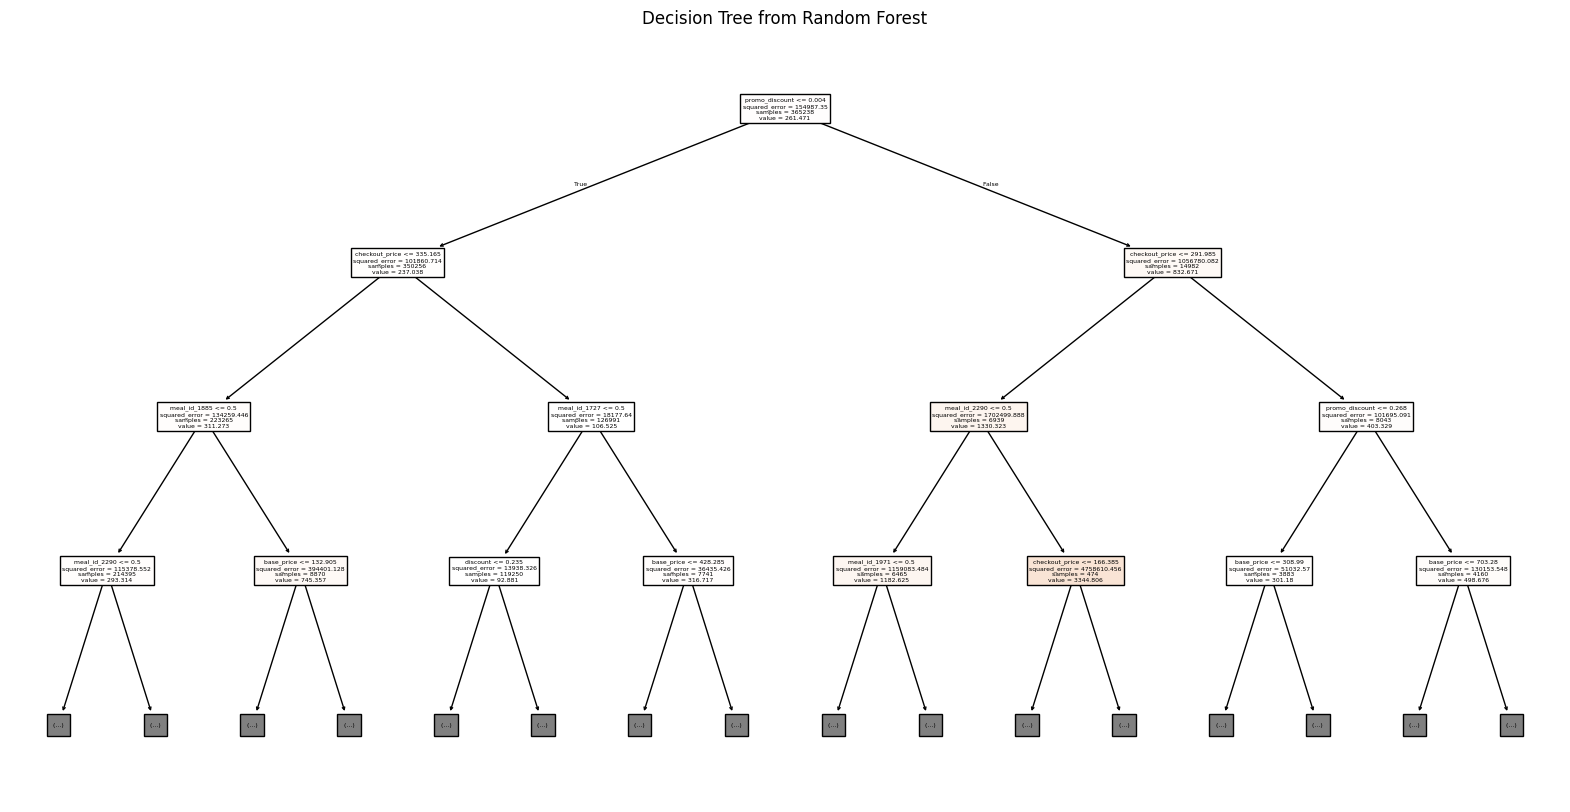

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot,feature_names=X.columns,max_depth=3,filled=True)
plt.title("Decision Tree from Random Forest")
plt.show()

In [ ]:
#visualization of features and output in linear regg